# n_neighbors = 5

In [2]:
import sys
from pathlib import Path
import os
import wandb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

CONFIG = {
    "n_neighbors": 5,
    "batch_size": 64,
    "project_name": "odysseus"
}

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "extracted_features_SPP").exists():
            return path
    raise FileNotFoundError(
        "Could not find data/extracted_features_SPP from the current working directory."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "extracted_features_SPP"
print(f"Project root: {PROJECT_ROOT}")
print(f"Feature directory: {DATA_DIR}")

# 1. Add project root to sys.path so we can import from src/
sys.path.append(str(PROJECT_ROOT))
from src.data_pipeline import CleanedGreekLettersDataset

# 2. Load the pre-split arrays 
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

print(f"Loaded Train Set - X: {X_train.shape}, y: {y_train.shape}")
print(f"Loaded Test Set  - X: {X_test.shape}, y: {y_test.shape}")

# 3. Use the dataset class as the source of truth for class mapping
# We can pass an arbitrary path here just to instantiate and get the class list
dummy_dataset = CleanedGreekLettersDataset(root_dir=PROJECT_ROOT / "data")
class_names = dummy_dataset.classes
idx_to_class = {v: k for k, v in dummy_dataset.class_to_idx.items()}
n_classes = len(class_names)
print(f"Classes: {n_classes} mapped successfully.")

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train Scaled: {X_train_scaled.shape}, Test Scaled: {X_test_scaled.shape}")

Project root: /Users/albert/Desktop/Uni_Klagenfurt/SS26/AI_ML/odysseus
Feature directory: /Users/albert/Desktop/Uni_Klagenfurt/SS26/AI_ML/odysseus/data/extracted_features_SPP
Loaded Train Set - X: (100224, 2048), y: (100224,)
Loaded Test Set  - X: (10977, 2048), y: (10977,)
Classes: 24 mapped successfully.
Train Scaled: (100224, 2048), Test Scaled: (10977, 2048)


In [3]:
def _as_float_tensor(array):
    return torch.from_numpy(array.astype(np.float32, copy=False))

def _majority_vote(nn_labels, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, labels in enumerate(nn_labels):
        counts = torch.bincount(labels.long(), minlength=n_classes)
        y_pred[row_idx] = int(counts.argmax())
    return y_pred

def _weighted_vote(nn_labels, weights, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, (labels, row_weights) in enumerate(zip(nn_labels, weights)):
        scores = torch.zeros(n_classes, dtype=torch.float64)
        scores.scatter_add_(0, labels.long(), row_weights.double())
        y_pred[row_idx] = int(scores.argmax())
    return y_pred

def predict_knn_euclidean(X_train, y_train, X_test, n_classes, k=5, batch_size=64, weighted=False):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    train_norm = (train * train).sum(dim=1)
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        dists_sq = (batch * batch).sum(dim=1, keepdim=True) + train_norm[None, :] - 2 * batch.matmul(train_t)
        nn_dists_sq, nn_idx = torch.topk(dists_sq, k=k, largest=False, dim=1)
        nn_labels = y_train_t[nn_idx]

        if weighted:
            weights = 1 / (torch.sqrt(torch.clamp(nn_dists_sq, min=0)) + 1e-12)
            batch_pred = _weighted_vote(nn_labels, weights, n_classes)
        else:
            batch_pred = _majority_vote(nn_labels, n_classes)

        y_pred[start_idx:end_idx] = batch_pred
        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred

def predict_knn_cosine_weighted(X_train, y_train, X_test, n_classes, k=5, batch_size=64):
    train = torch.nn.functional.normalize(_as_float_tensor(X_train), p=2, dim=1)
    test = torch.nn.functional.normalize(_as_float_tensor(X_test), p=2, dim=1)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        similarities = batch.matmul(train_t)
        nn_similarities, nn_idx = torch.topk(similarities, k=k, largest=True, dim=1)
        nn_labels = y_train_t[nn_idx]
        cosine_distances = 1 - nn_similarities
        weights = 1 / (torch.clamp(cosine_distances, min=0) + 1e-12)
        y_pred[start_idx:end_idx] = _weighted_vote(nn_labels, weights, n_classes)

        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred

def run_knn_experiment(run_name, predict_fn, kwargs, config_params, project_name=CONFIG["project_name"]):
    """
    Universal wrapper to evaluate KNN logic, calculate metrics, and handle wandb logging.
    """
    wandb.init(project=project_name, name=run_name, job_type="modeling", config=config_params)
    
    print(f"\n{'='*50}\nStarting Experiment: {run_name}\n{'='*50}")
    
    y_pred = predict_fn(**kwargs)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Results for {run_name}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")
    print("\nClassification report per class:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    # Log metrics to W&B
    wandb.run.summary["final_accuracy"] = accuracy
    wandb.run.summary["final_macro_f1"] = macro_f1
    wandb.run.summary["final_weighted_f1"] = weighted_f1

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=sorted(idx_to_class), normalize="true")
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="viridis", cbar=True,
        xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7}
    )
    plt.title(f"Normalized Confusion Matrix - {run_name} (Acc: {accuracy:.2f})")
    plt.xlabel("Predicted Letter")
    plt.ylabel("True Letter")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save to wandb
    cm_filename = f"knn_cm_{run_name.replace(' ', '_').lower()}.png"
    plt.savefig(cm_filename, dpi=300)
    wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
    plt.show()
    
    wandb.finish()
    
    return y_pred

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/albert/.netrc.
wandb: Currently logged in as: albert-heinrichs-shop (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Starting Experiment: Euclidean majority KNN
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for Euclidean majority KNN
Accuracy:    0.3173
Macro-F1:    0.2415
Weighted-F1: 0.3034

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.2269    0.7280    0.3460      1044
        Beta     0.0619    0.0566    0.0591       106
         Chi     0.1343    0.1842    0.1553       304
       Delta     0.2597    0.3193    0.2864       379
     Epsilon     0.3756    0.4066    0.3905       787
         Eta     0.3254    0.1798    0.2316       534
       Gamma     0.1194    0.0964    0.1067       166
        Iota 

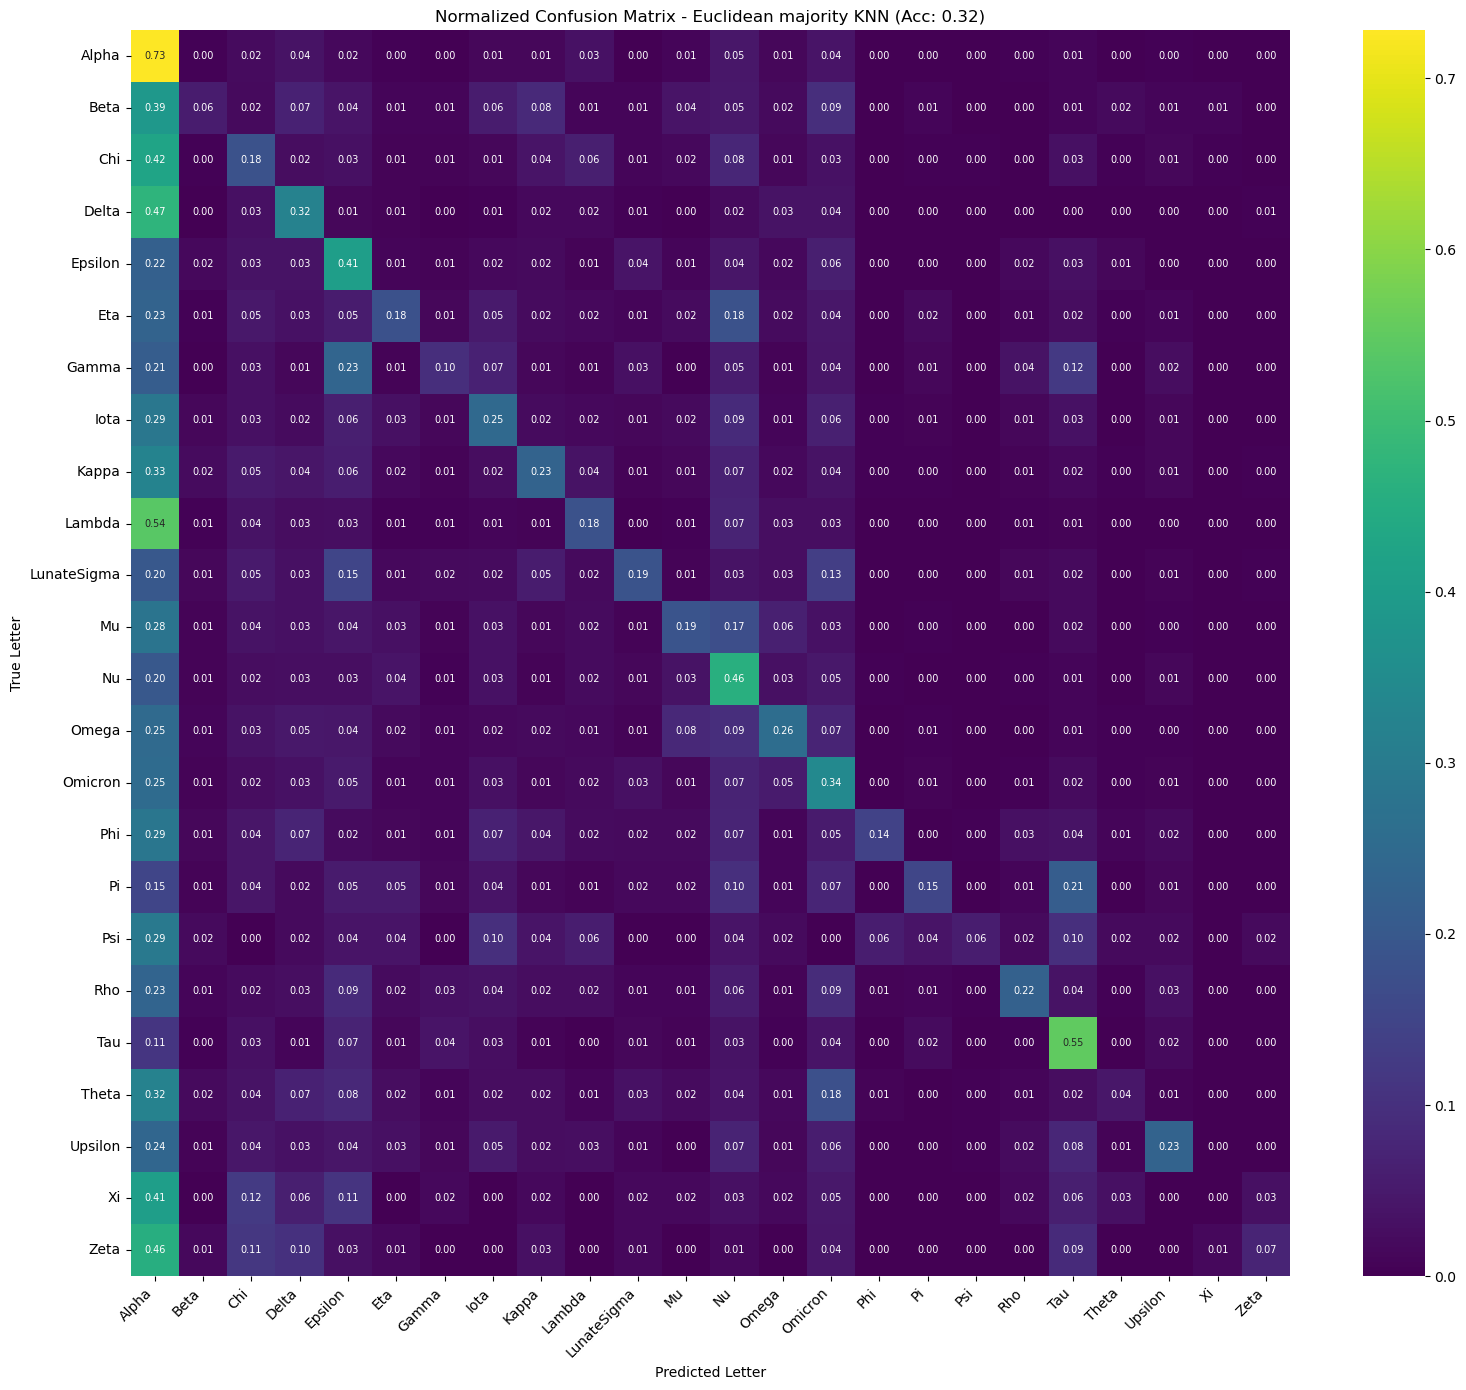

final_accuracy,0.3173
final_macro_f1,0.2415
final_weighted_f1,0.3034


In [4]:
config_eucl_maj = {
    "model_type": "KNN",
    "distance_metric": "euclidean",
    "weighting": "majority",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

y_pred_euclidean_majority = run_knn_experiment(
    run_name="Euclidean majority KNN",
    predict_fn=predict_knn_euclidean,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"],
        "weighted": False
    },
    config_params=config_eucl_maj
)


Starting Experiment: Euclidean distance-weighted KNN
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for Euclidean distance-weighted KNN
Accuracy:    0.3239
Macro-F1:    0.2488
Weighted-F1: 0.3092

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.3049    0.5718    0.3977      1044
        Beta     0.1579    0.0566    0.0833       106
         Chi     0.1889    0.1678    0.1777       304
       Delta     0.3297    0.3219    0.3258       379
     Epsilon     0.4123    0.3672    0.3884       787
         Eta     0.3374    0.1554    0.2128       534
       Gamma     0.1339    0.0904    0.1079      

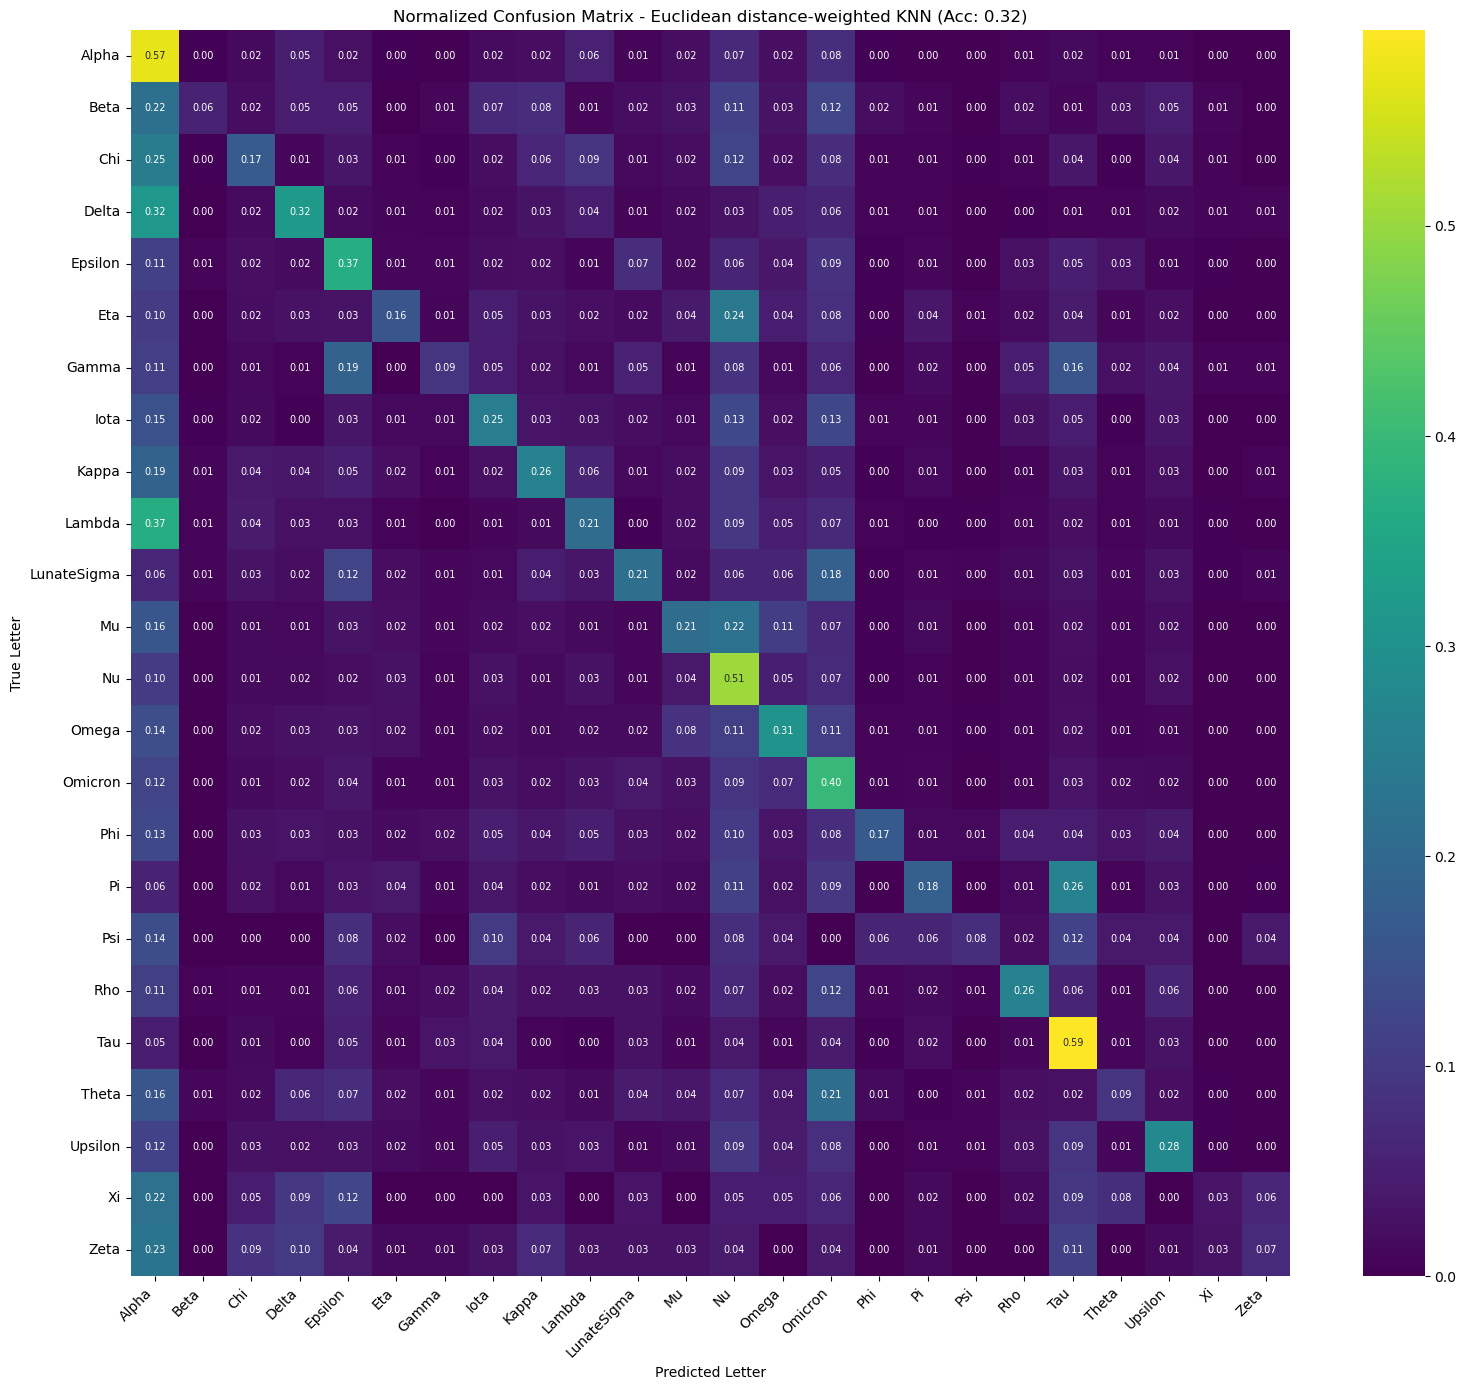

final_accuracy,0.32386
final_macro_f1,0.24883
final_weighted_f1,0.30923


In [5]:
config_eucl_weight = {
    "model_type": "KNN",
    "distance_metric": "euclidean",
    "weighting": "distance",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

y_pred_euclidean_weighted = run_knn_experiment(
    run_name="Euclidean distance-weighted KNN",
    predict_fn=predict_knn_euclidean,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"],
        "weighted": True
    },
    config_params=config_eucl_weight
)


Starting Experiment: Cosine distance-weighted KNN
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for Cosine distance-weighted KNN
Accuracy:    0.4081
Macro-F1:    0.3314
Weighted-F1: 0.3999

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.4600    0.5010    0.4796      1044
        Beta     0.3226    0.1887    0.2381       106
         Chi     0.3362    0.2599    0.2931       304
       Delta     0.4905    0.4090    0.4460       379
     Epsilon     0.4737    0.5388    0.5042       787
         Eta     0.3730    0.2996    0.3323       534
       Gamma     0.2195    0.1627    0.1869       166
 

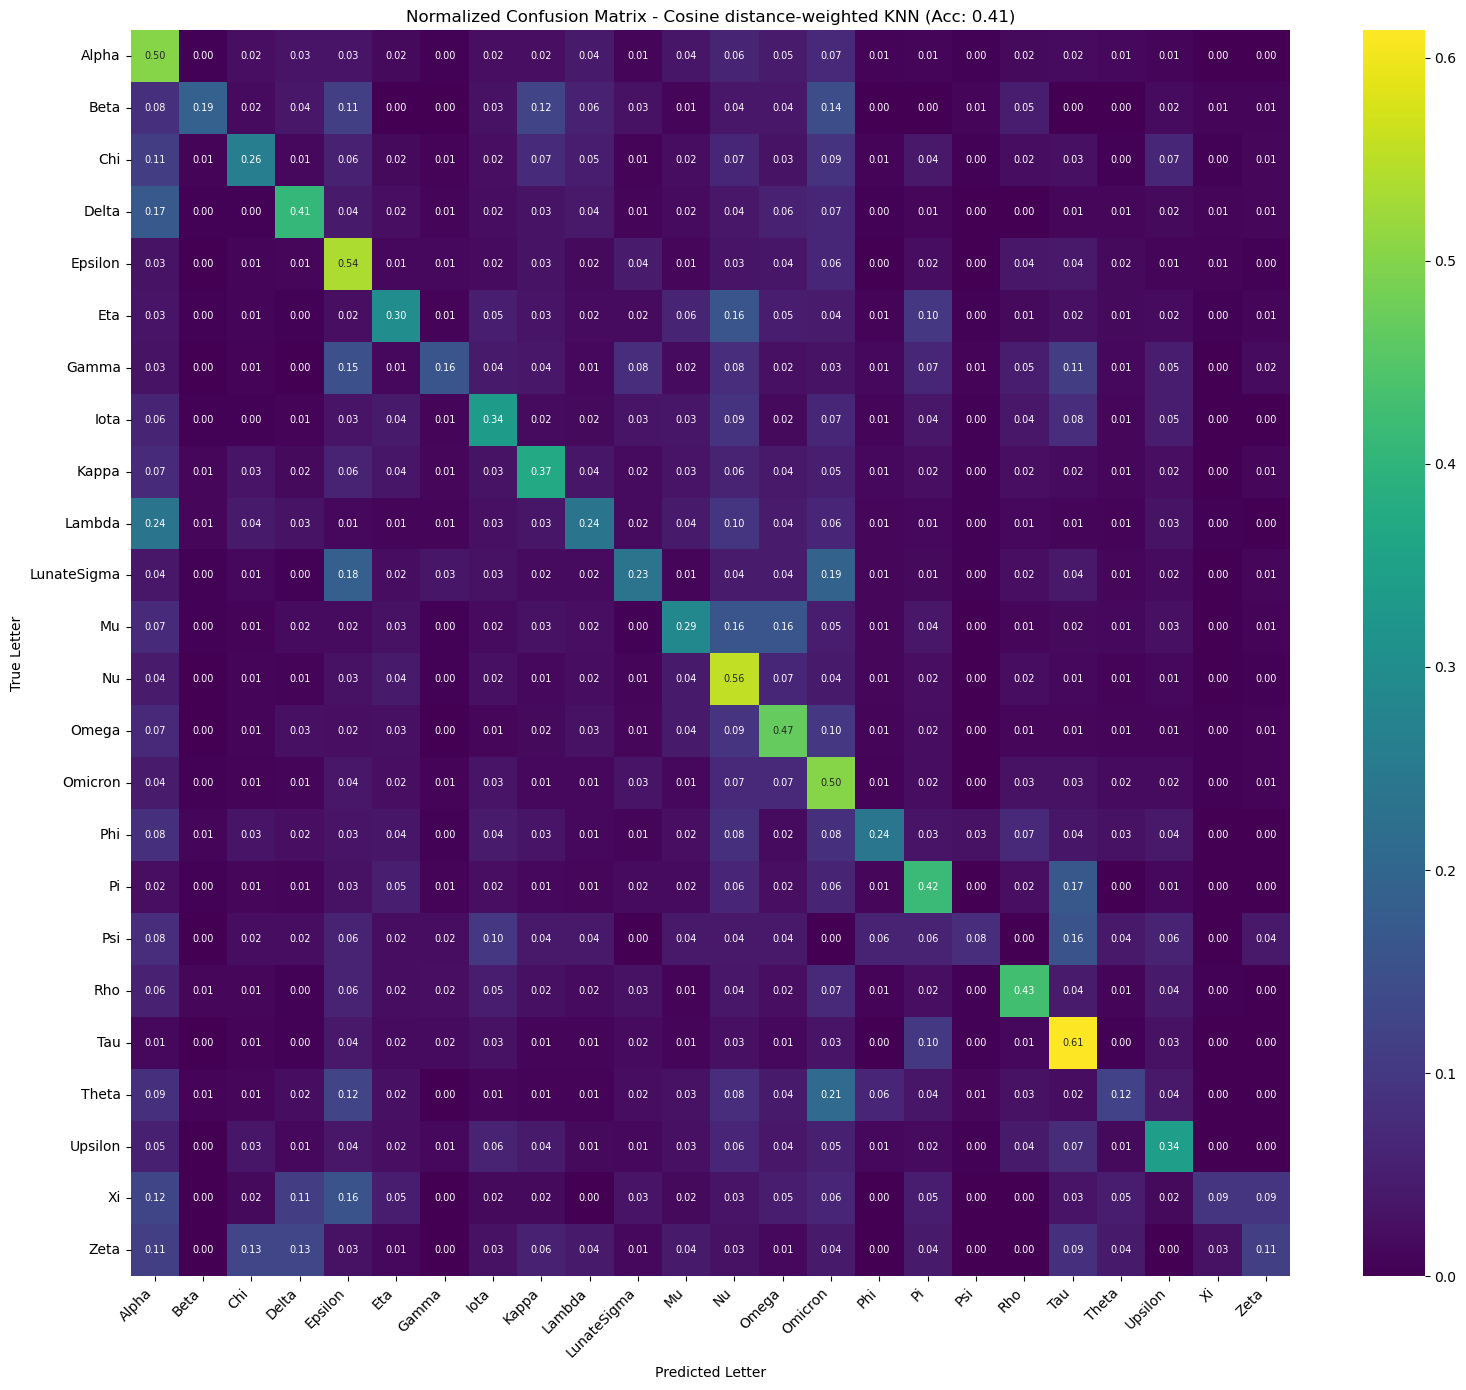

final_accuracy,0.40813
final_macro_f1,0.33138
final_weighted_f1,0.39994


In [6]:
config_cos_weight = {
    "model_type": "KNN",
    "distance_metric": "cosine",
    "weighting": "distance",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

y_pred_cosine_weighted = run_knn_experiment(
    run_name="Cosine distance-weighted KNN",
    predict_fn=predict_knn_cosine_weighted,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"]
    },
    config_params=config_cos_weight
)

# n_neighbors = 7


In [13]:
import sys
from pathlib import Path
import os
import wandb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

CONFIG = {
    "n_neighbors": 7,
    "batch_size": 64,
    "project_name": "odysseus",
    "tuning_neighbors": [3, 5, 7, 9, 11],
    "tuning_cv_folds": 3,
}

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "extracted_features").exists():
            return path
    raise FileNotFoundError(
        "Could not find data/extracted_features from the current working directory."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "extracted_features"
print(f"Project root: {PROJECT_ROOT}")
print(f"Feature directory: {DATA_DIR}")

# 1. Add project root to sys.path so we can import from src/
sys.path.append(str(PROJECT_ROOT))
from src.data_pipeline import CleanedGreekLettersDataset

# 2. Load the pre-split arrays directly to prevent data leakage
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

print(f"Loaded Train Set - X: {X_train.shape}, y: {y_train.shape}")
print(f"Loaded Test Set  - X: {X_test.shape}, y: {y_test.shape}")

# 3. Use the dataset class as the source of truth for class mapping
dummy_dataset = CleanedGreekLettersDataset(root_dir=PROJECT_ROOT / "data")
class_names = dummy_dataset.classes
idx_to_class = {v: k for k, v in dummy_dataset.class_to_idx.items()}
n_classes = len(class_names)
print(f"Classes: {n_classes} mapped successfully.")

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train Scaled: {X_train_scaled.shape}, Test Scaled: {X_test_scaled.shape}")

Project root: /Users/albert/Desktop/Uni_Klagenfurt/SS26/AI_ML/odysseus
Feature directory: /Users/albert/Desktop/Uni_Klagenfurt/SS26/AI_ML/odysseus/data/extracted_features
Loaded Train Set - X: (100224, 512), y: (100224,)
Loaded Test Set  - X: (10977, 512), y: (10977,)
Classes: 24 mapped successfully.
Train Scaled: (100224, 512), Test Scaled: (10977, 512)


In [8]:
def _as_float_tensor(array):
    return torch.from_numpy(array.astype(np.float32, copy=False))

def _majority_vote(nn_labels, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, labels in enumerate(nn_labels):
        counts = torch.bincount(labels.long(), minlength=n_classes)
        y_pred[row_idx] = int(counts.argmax())
    return y_pred

def _weighted_vote(nn_labels, weights, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, (labels, row_weights) in enumerate(zip(nn_labels, weights)):
        scores = torch.zeros(n_classes, dtype=torch.float64)
        scores.scatter_add_(0, labels.long(), row_weights.double())
        y_pred[row_idx] = int(scores.argmax())
    return y_pred

def predict_knn_euclidean(X_train, y_train, X_test, n_classes, k=5, batch_size=64, weighted=False):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    train_norm = (train * train).sum(dim=1)
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        dists_sq = (batch * batch).sum(dim=1, keepdim=True) + train_norm[None, :] - 2 * batch.matmul(train_t)
        nn_dists_sq, nn_idx = torch.topk(dists_sq, k=k, largest=False, dim=1)
        nn_labels = y_train_t[nn_idx]

        if weighted:
            weights = 1 / (torch.sqrt(torch.clamp(nn_dists_sq, min=0)) + 1e-12)
            batch_pred = _weighted_vote(nn_labels, weights, n_classes)
        else:
            batch_pred = _majority_vote(nn_labels, n_classes)

        y_pred[start_idx:end_idx] = batch_pred
        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred

def predict_knn_cosine_weighted(X_train, y_train, X_test, n_classes, k=5, batch_size=64):
    train = torch.nn.functional.normalize(_as_float_tensor(X_train), p=2, dim=1)
    test = torch.nn.functional.normalize(_as_float_tensor(X_test), p=2, dim=1)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        similarities = batch.matmul(train_t)
        nn_similarities, nn_idx = torch.topk(similarities, k=k, largest=True, dim=1)
        nn_labels = y_train_t[nn_idx]
        cosine_distances = 1 - nn_similarities
        weights = 1 / (torch.clamp(cosine_distances, min=0) + 1e-12)
        y_pred[start_idx:end_idx] = _weighted_vote(nn_labels, weights, n_classes)

        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred

def run_knn_experiment(run_name, predict_fn, kwargs, config_params, project_name=CONFIG["project_name"]):
    """
    Universal wrapper to evaluate KNN logic, calculate metrics, and handle wandb logging.
    """
    wandb.init(project=project_name, name=run_name, job_type="modeling", config=config_params)
    
    print(f"\n{'='*50}\nStarting Experiment: {run_name}\n{'='*50}")
    
    y_pred = predict_fn(**kwargs)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Results for {run_name}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")
    print("\nClassification report per class:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    # Log metrics to W&B
    wandb.run.summary["final_accuracy"] = accuracy
    wandb.run.summary["final_macro_f1"] = macro_f1
    wandb.run.summary["final_weighted_f1"] = weighted_f1

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=sorted(idx_to_class), normalize="true")
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="viridis", cbar=True,
        xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7}
    )
    plt.title(f"Normalized Confusion Matrix - {run_name} (Acc: {accuracy:.2f})")
    plt.xlabel("Predicted Letter")
    plt.ylabel("True Letter")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save to wandb
    cm_filename = f"knn_cm_{run_name.replace(' ', '_').lower()}.png"
    plt.savefig(cm_filename, dpi=300)
    wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
    plt.show()
    
    wandb.finish()
    
    return y_pred


Starting Experiment: Euclidean majority KNN (k=7)
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for Euclidean majority KNN (k=7)
Accuracy:    0.3359
Macro-F1:    0.2510
Weighted-F1: 0.3182

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.2410    0.7414    0.3637      1044
        Beta     0.0851    0.0377    0.0523       106
         Chi     0.1495    0.1579    0.1536       304
       Delta     0.3439    0.3430    0.3435       379
     Epsilon     0.4201    0.4142    0.4171       787
         Eta     0.3802    0.1723    0.2371       534
       Gamma     0.1566    0.0783    0.1044       166
 

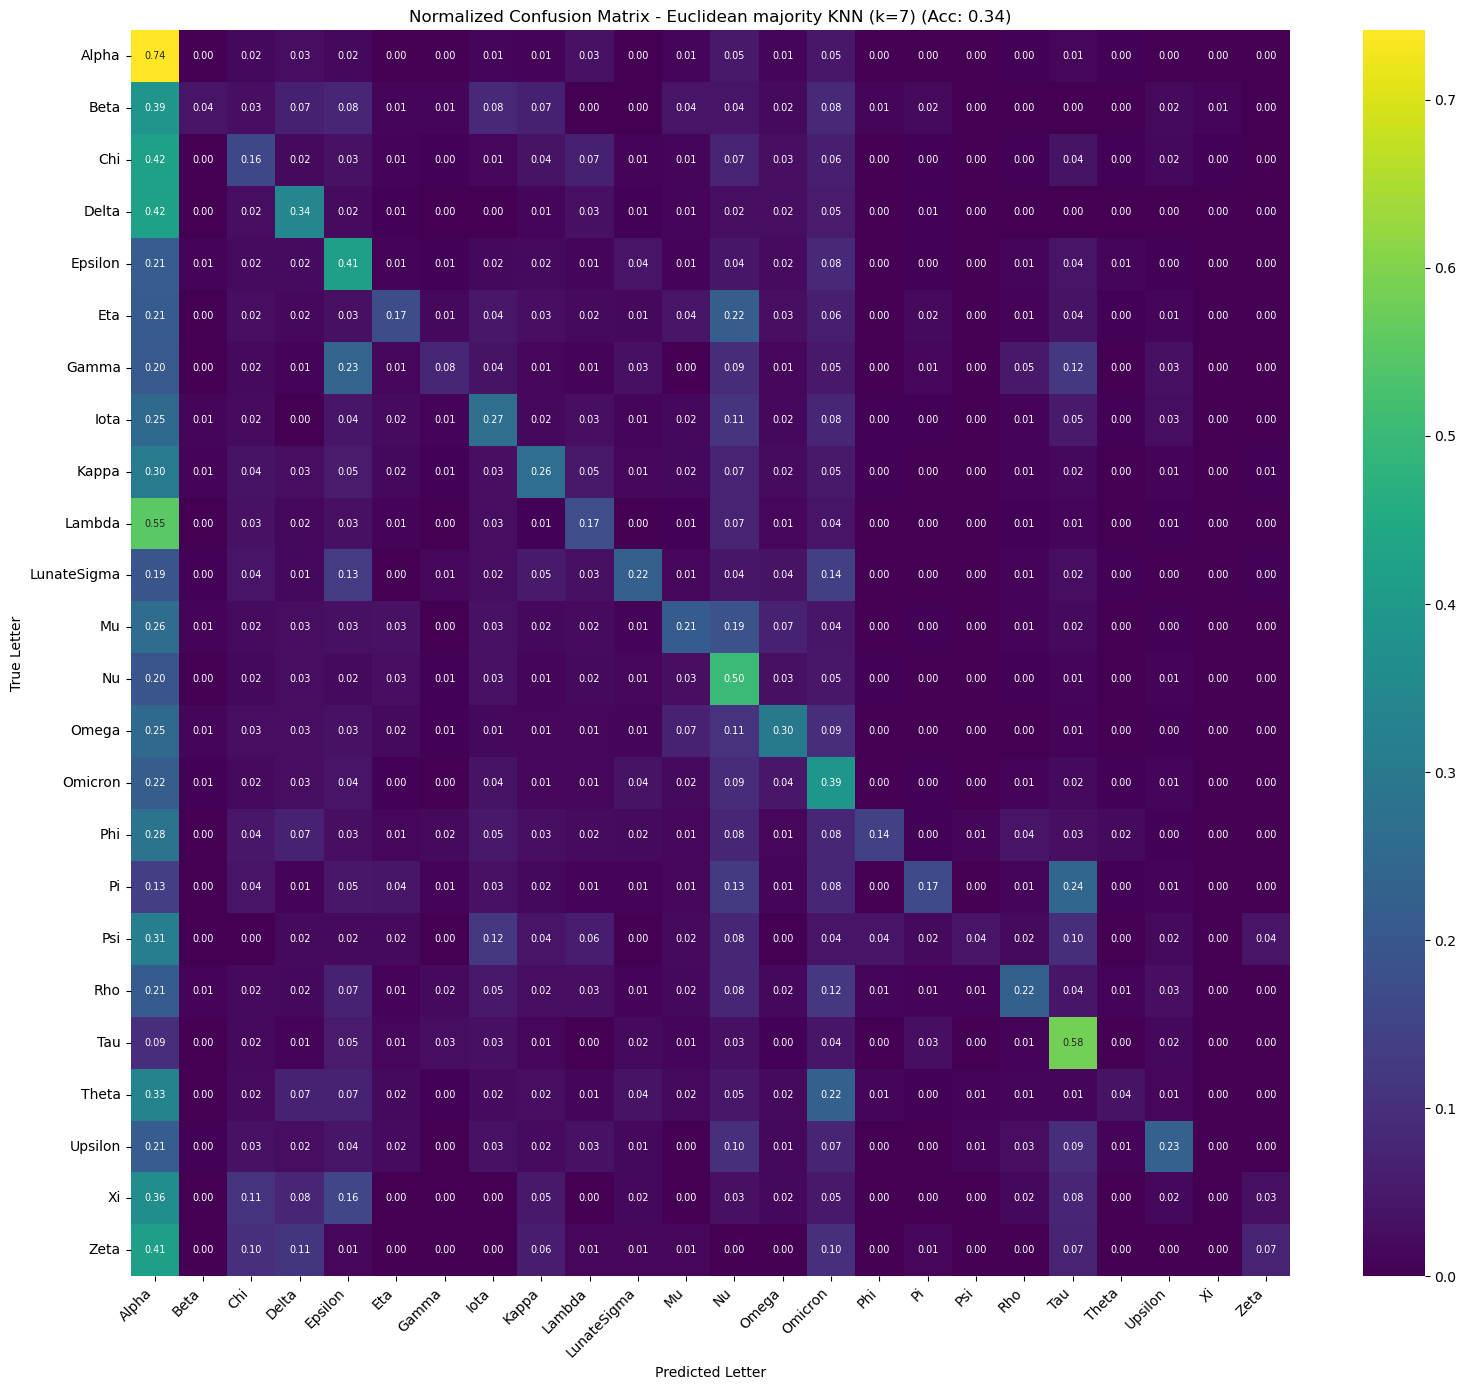

final_accuracy,0.33588
final_macro_f1,0.25101
final_weighted_f1,0.31822


In [9]:
config_eucl_maj = {
    "model_type": "KNN",
    "distance_metric": "euclidean",
    "weighting": "majority",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

y_pred_euclidean_majority = run_knn_experiment(
    run_name=f"Euclidean majority KNN (k={CONFIG['n_neighbors']})",
    predict_fn=predict_knn_euclidean,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"],
        "weighted": False
    },
    config_params=config_eucl_maj
)


Starting Experiment: Euclidean distance-weighted KNN (k=7)
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for Euclidean distance-weighted KNN (k=7)
Accuracy:    0.3489
Macro-F1:    0.2659
Weighted-F1: 0.3306

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.3028    0.6274    0.4085      1044
        Beta     0.2400    0.0566    0.0916       106
         Chi     0.2017    0.1546    0.1750       304
       Delta     0.3855    0.3509    0.3674       379
     Epsilon     0.4570    0.3914    0.4216       787
         Eta     0.4044    0.1704    0.2398       534
       Gamma     0.1625    0.0783    

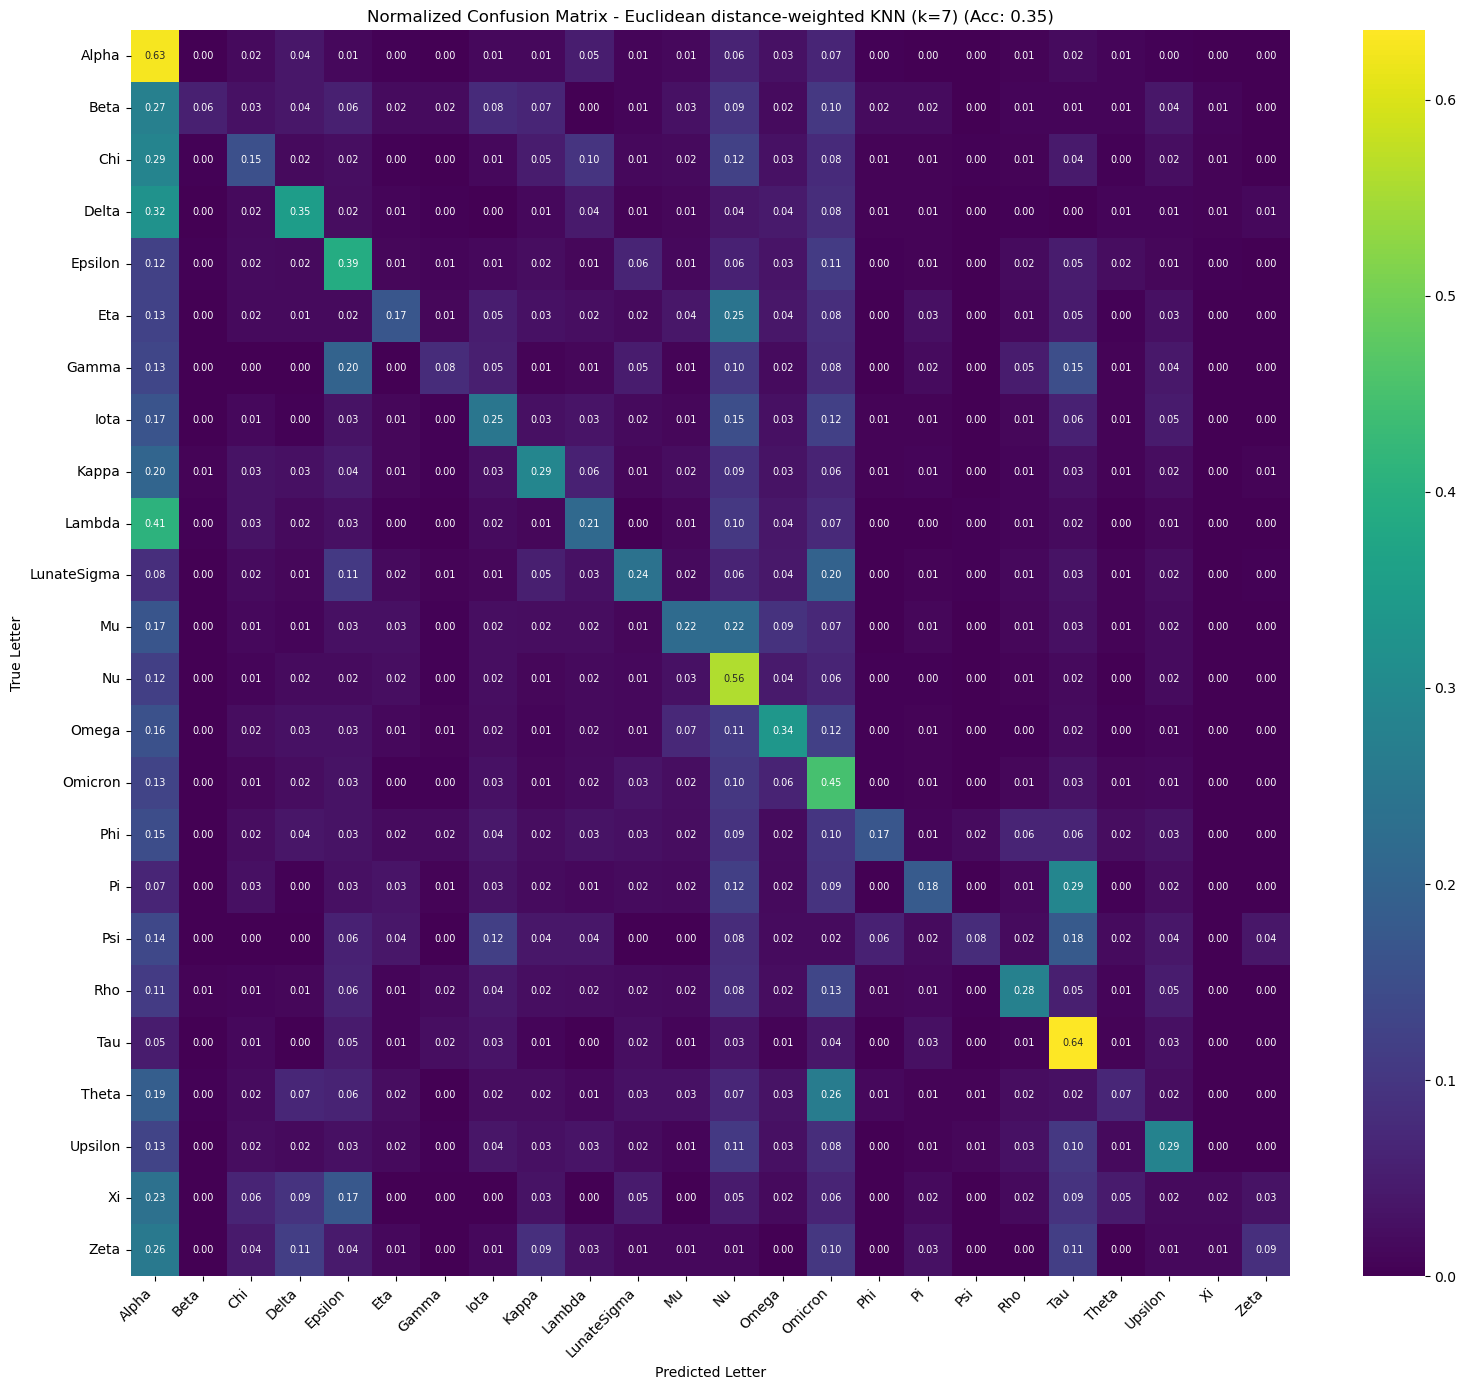

final_accuracy,0.34891
final_macro_f1,0.26589
final_weighted_f1,0.33062


In [10]:
config_eucl_weight = {
    "model_type": "KNN",
    "distance_metric": "euclidean",
    "weighting": "distance",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

y_pred_euclidean_weighted = run_knn_experiment(
    run_name=f"Euclidean distance-weighted KNN (k={CONFIG['n_neighbors']})",
    predict_fn=predict_knn_euclidean,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"],
        "weighted": True
    },
    config_params=config_eucl_weight
)


Starting Experiment: Cosine distance-weighted KNN (k=7)
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for Cosine distance-weighted KNN (k=7)
Accuracy:    0.4273
Macro-F1:    0.3456
Weighted-F1: 0.4169

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.4688    0.5326    0.4987      1044
        Beta     0.3913    0.1698    0.2368       106
         Chi     0.3487    0.2730    0.3063       304
       Delta     0.5113    0.4169    0.4593       379
     Epsilon     0.4925    0.5832    0.5340       787
         Eta     0.4227    0.3071    0.3557       534
       Gamma     0.2667    0.1687    0.2066

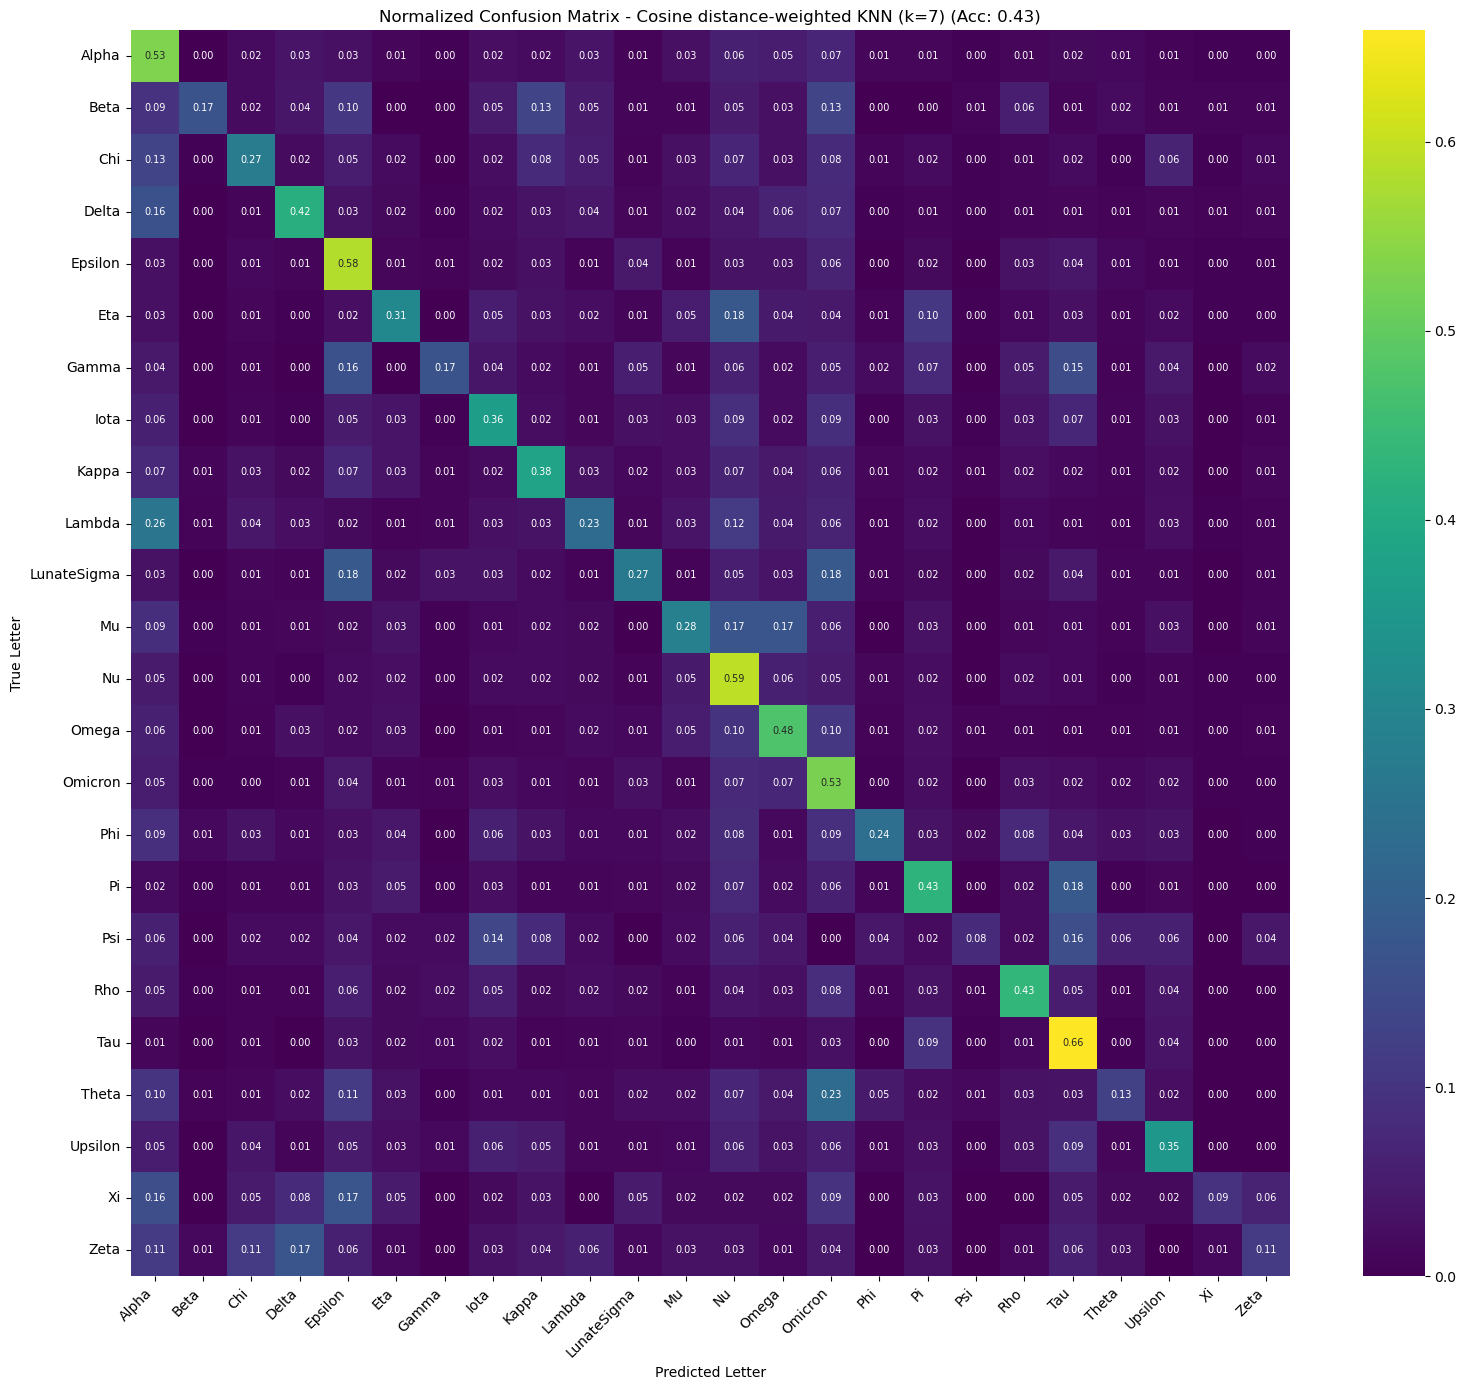

final_accuracy,0.42735
final_macro_f1,0.34556
final_weighted_f1,0.41687


In [11]:
config_cos_weight = {
    "model_type": "KNN",
    "distance_metric": "cosine",
    "weighting": "distance",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "SPP_2x2",
    "vgg16_blocks": "all"
}

y_pred_cosine_weighted = run_knn_experiment(
    run_name=f"Cosine distance-weighted KNN (k={CONFIG['n_neighbors']})",
    predict_fn=predict_knn_cosine_weighted,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"]
    },
    config_params=config_cos_weight
)


Starting Experiment: GAP Cosine distance-weighted KNN (k=7)
Predicted 640/10977
Predicted 1280/10977
Predicted 1920/10977
Predicted 2560/10977
Predicted 3200/10977
Predicted 3840/10977
Predicted 4480/10977
Predicted 5120/10977
Predicted 5760/10977
Predicted 6400/10977
Predicted 7040/10977
Predicted 7680/10977
Predicted 8320/10977
Predicted 8960/10977
Predicted 9600/10977
Predicted 10240/10977
Predicted 10880/10977
Predicted 10977/10977
Results for GAP Cosine distance-weighted KNN (k=7)
Accuracy:    0.2991
Macro-F1:    0.2364
Weighted-F1: 0.2900

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.3109    0.3400    0.3248      1044
        Beta     0.0862    0.0472    0.0610       106
         Chi     0.2241    0.2632    0.2421       304
       Delta     0.3102    0.2243    0.2603       379
     Epsilon     0.3396    0.3914    0.3636       787
         Eta     0.2504    0.2678    0.2588       534
       Gamma     0.0893    0.0301  

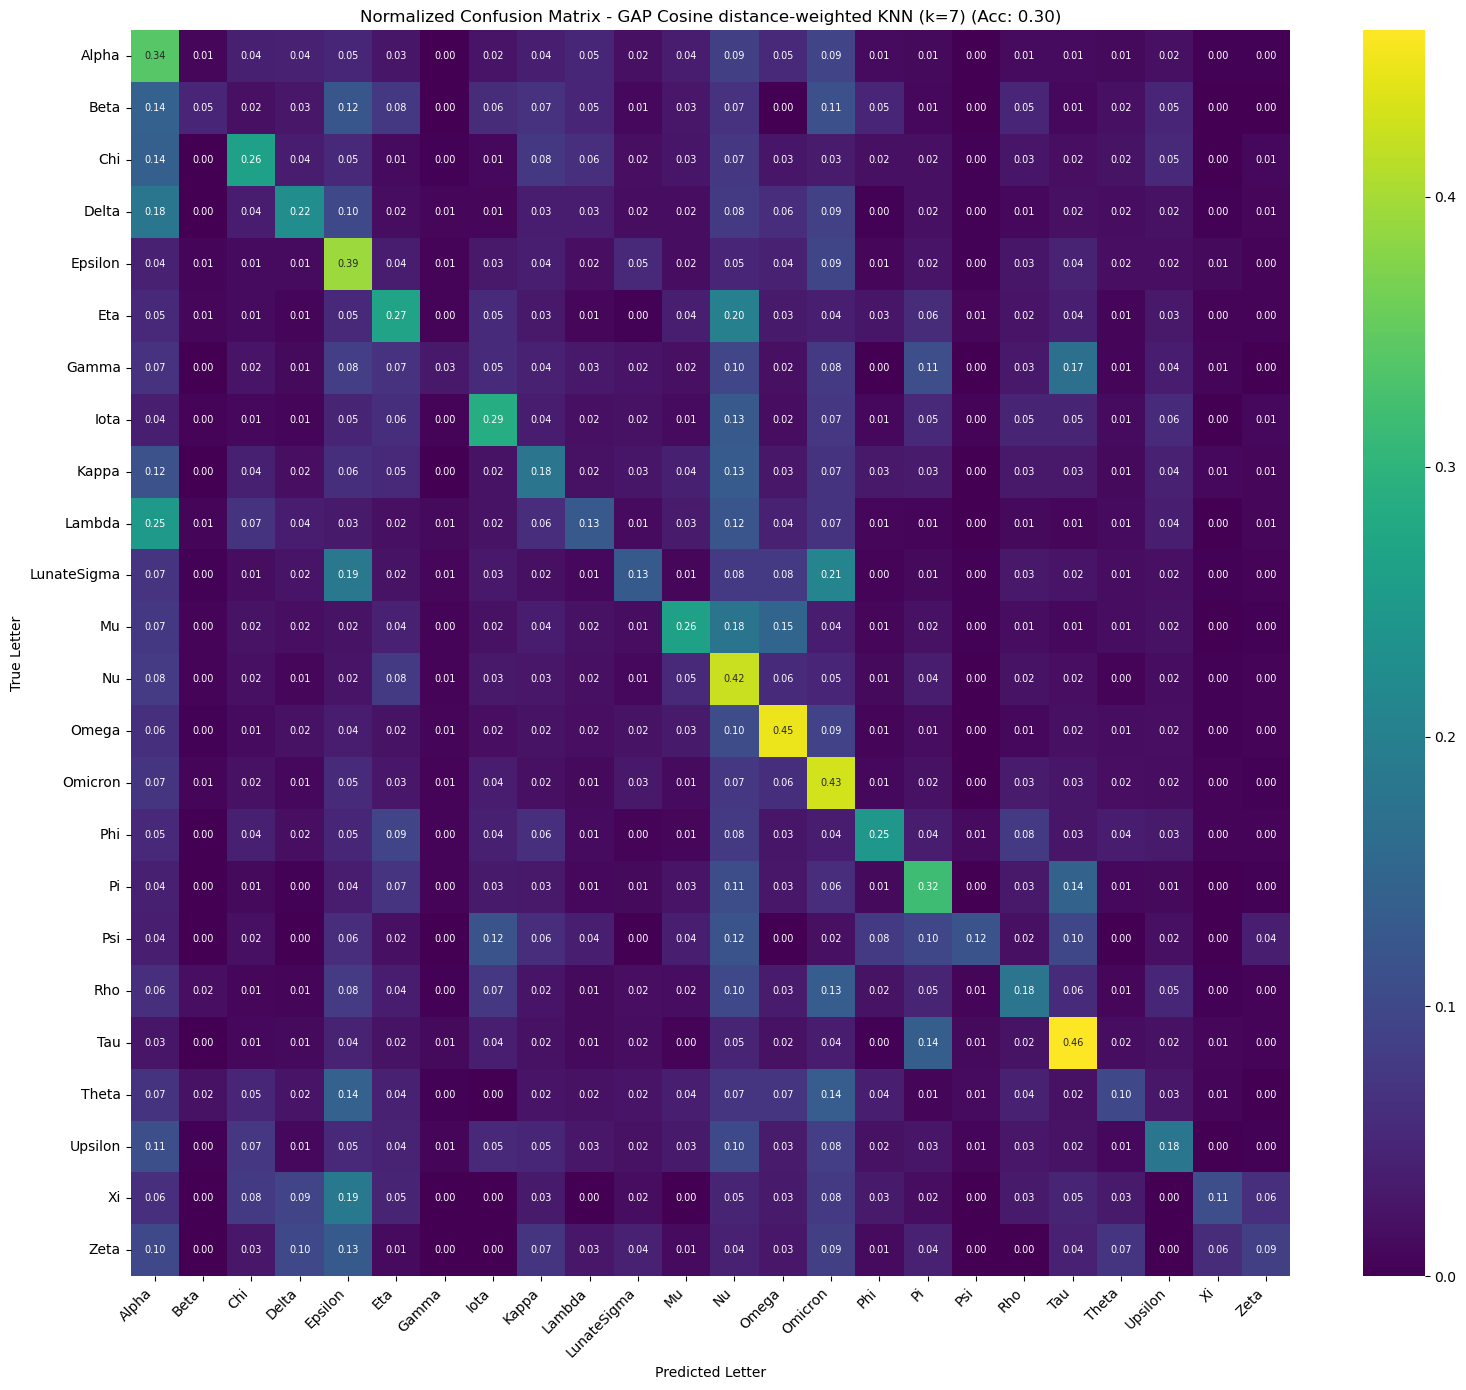

final_accuracy,0.29908
final_macro_f1,0.2364
final_weighted_f1,0.29002


In [14]:
config_cos_weight = {
    "model_type": "KNN",
    "distance_metric": "cosine",
    "weighting": "distance",
    "n_neighbors": CONFIG["n_neighbors"],
    "batch_size": CONFIG["batch_size"],
    "pooling_strategy": "GAP",
    "vgg16_blocks": "all"
}

y_pred_cosine_weighted = run_knn_experiment(
    run_name=f"GAP Cosine distance-weighted KNN (k={CONFIG['n_neighbors']})",
    predict_fn=predict_knn_cosine_weighted,
    kwargs={
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_test": X_test_scaled,
        "n_classes": n_classes,
        "k": CONFIG["n_neighbors"],
        "batch_size": CONFIG["batch_size"]
    },
    config_params=config_cos_weight
)

Subsampling training data for GridSearch to ensure reasonable execution time...
Tuning data shape: (50112, 2048)

Starting GridSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best CV macro-F1: 0.4379
Best params:
  knn__metric: cosine
  knn__n_neighbors: 11
  knn__weights: distance
  normalizer: Normalizer

Refitting best model on the FULL training set...
Generating predictions on the 11k test set...
Note: Scikit-learn CPU predictions will take a few minutes (unlike the vectorized PyTorch approaches earlier).

Results for Tuned KNN (cosine, k=11, distance)
Accuracy:    0.4459
Macro-F1:    0.3589
Weighted-F1: 0.4326

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.4754    0.5651    0.5164      1044
        Beta     0.3529    0.1698    0.2293       106
         Chi     0.3710    0.3026    0.3333       304
       Delta     0.5469    0.4617    0.5007       379
     Epsilon     0.4860    0.5934    0.5343   

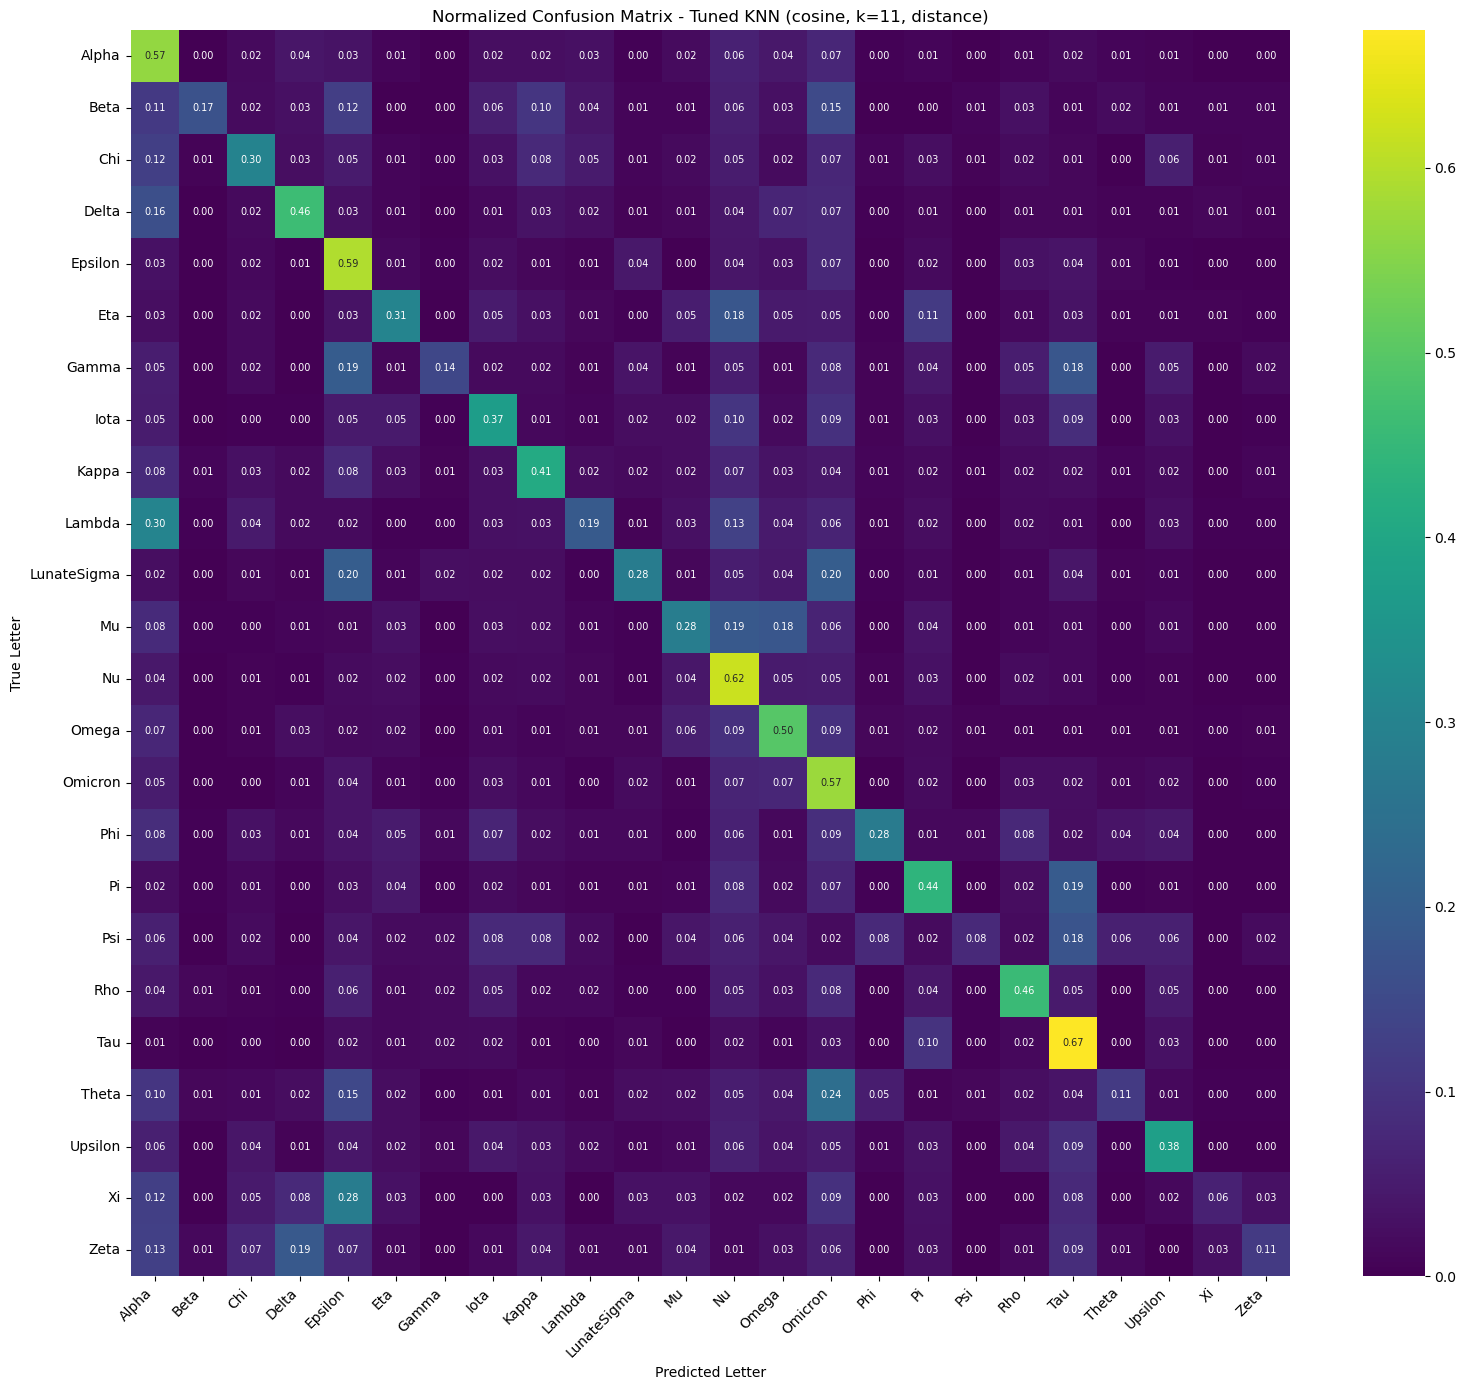

cv_macro_f1,0.43788
final_accuracy,0.44593
final_macro_f1,0.35888
final_weighted_f1,0.43257


In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
import wandb

# Initialize W&B run
wandb.init(project=CONFIG["project_name"], name="Tuned KNN (GridSearch)", job_type="tuning")

# --- PERFORMANCE FIX ---
# Running 90 fits on 100k samples x 2048 dims will take long
# We take a 50% stratified subset to quickly find the best hyperparameters.
print("Subsampling training data for GridSearch to ensure reasonable execution time...")
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=0.5, random_state=42, stratify=y_train
)
print(f"Tuning data shape: {X_tune.shape}")

tuning_pipeline = Pipeline([
    ("normalizer", "passthrough"),
    ("knn", KNeighborsClassifier(algorithm="brute")),
])

param_grid = [
    {
        "normalizer": ["passthrough"],
        "knn__n_neighbors": CONFIG["tuning_neighbors"],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    },
    {
        "normalizer": [Normalizer()],
        "knn__n_neighbors": CONFIG["tuning_neighbors"],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["cosine"],
    },
]

cv = StratifiedKFold(
    n_splits=CONFIG["tuning_cv_folds"],
    shuffle=True,
    random_state=42,
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

print("\nStarting GridSearchCV...")
grid_search.fit(X_tune, y_tune)

# Clean up parameter dictionary for logging
best_params = grid_search.best_params_.copy()
best_params["normalizer"] = type(best_params["normalizer"]).__name__ if best_params["normalizer"] != "passthrough" else "passthrough"

print(f"\nBest CV macro-F1: {grid_search.best_score_:.4f}")
print("Best params:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Log tuning results to W&B
wandb.config.update(best_params)
wandb.run.summary["cv_macro_f1"] = grid_search.best_score_

# --- FINAL EVALUATION ---
print("\nRefitting best model on the FULL training set...")
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)

print("Generating predictions on the 11k test set...")
print("Note: Scikit-learn CPU predictions will take a few minutes (unlike the vectorized PyTorch approaches earlier).")
y_pred_tuned = best_model.predict(X_test_scaled)

# Metrics
approach_name = f"Tuned KNN ({best_params['knn__metric']}, k={best_params['knn__n_neighbors']}, {best_params['knn__weights']})"
accuracy = accuracy_score(y_test, y_pred_tuned)
macro_f1 = f1_score(y_test, y_pred_tuned, average="macro")
weighted_f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"\nResults for {approach_name}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Macro-F1:    {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")
print("\nClassification report per class:")
print(classification_report(y_test, y_pred_tuned, target_names=class_names, digits=4))

# Log metrics to W&B
wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1
wandb.run.summary["final_weighted_f1"] = weighted_f1

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=sorted(idx_to_class), normalize="true")
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="viridis", cbar=True,
    xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7}
)
plt.title(f"Normalized Confusion Matrix - {approach_name}")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Save and upload
cm_filename = "knn_cm_tuned.png"
plt.savefig(cm_filename, dpi=300)
wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
plt.show()

wandb.finish()

Subsampling training data for GridSearch to ensure reasonable execution time...
Tuning data shape: (50112, 512)

Starting GridSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/envs/odysseus/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best CV macro-F1: 0.3204
Best params:
  knn__metric: cosine
  knn__n_neighbors: 9
  knn__weights: distance
  normalizer: Normalizer

Refitting best model on the FULL training set...
Generating predictions on the 11k test set...
Note: Scikit-learn CPU predictions will take a few minutes (unlike the vectorized PyTorch approaches earlier).

Results for Tuned KNN (cosine, k=9, distance)
Accuracy:    0.3086
Macro-F1:    0.2400
Weighted-F1: 0.2971

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.3161    0.3755    0.3433      1044
        Beta     0.1163    0.0472    0.0671       106
         Chi     0.2226    0.2467    0.2340       304
       Delta     0.3220    0.2243    0.2644       379
     Epsilon     0.3476    0.4015    0.3726       787
         Eta     0.2500    0.2584    0.2541       534
       Gamma     0.0980    0.0301    0.0461       166
        Iota     0.2981    0.3187    0.3080       433
       Kappa     0.2240    0.164

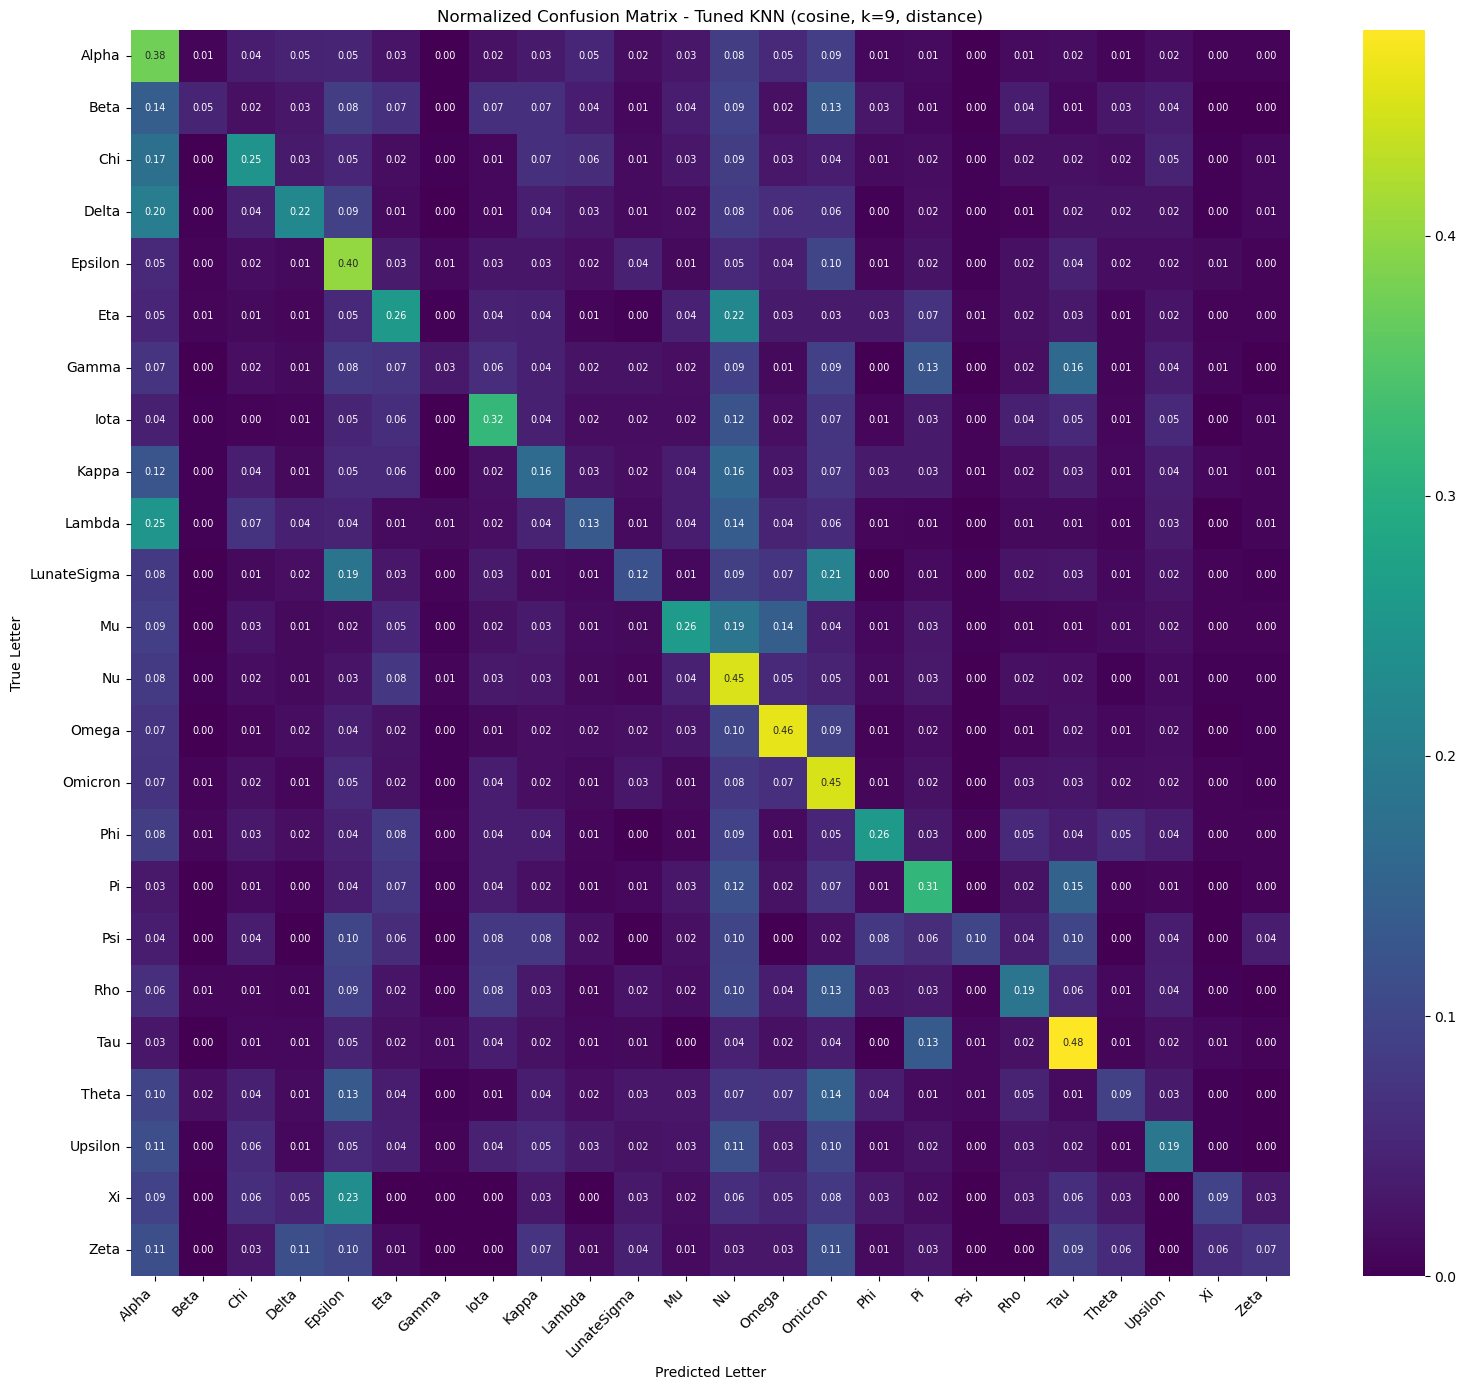

cv_macro_f1,0.32043
final_accuracy,0.30855
final_macro_f1,0.23998
final_weighted_f1,0.2971


In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
import wandb

# Initialize W&B run
wandb.init(project=CONFIG["project_name"], name="GAP Tuned KNN (GridSearch)", job_type="tuning")

# --- PERFORMANCE FIX ---
# Running 90 fits on 100k samples x 2048 dims will take long
# We take a 50% stratified subset to quickly find the best hyperparameters.
print("Subsampling training data for GridSearch to ensure reasonable execution time...")
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=0.5, random_state=42, stratify=y_train
)
print(f"Tuning data shape: {X_tune.shape}")

tuning_pipeline = Pipeline([
    ("normalizer", "passthrough"),
    ("knn", KNeighborsClassifier(algorithm="brute")),
])

param_grid = [
    {
        "normalizer": ["passthrough"],
        "knn__n_neighbors": CONFIG["tuning_neighbors"],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    },
    {
        "normalizer": [Normalizer()],
        "knn__n_neighbors": CONFIG["tuning_neighbors"],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["cosine"],
    },
]

cv = StratifiedKFold(
    n_splits=CONFIG["tuning_cv_folds"],
    shuffle=True,
    random_state=42,
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

print("\nStarting GridSearchCV...")
grid_search.fit(X_tune, y_tune)

# Clean up parameter dictionary for logging
best_params = grid_search.best_params_.copy()
best_params["normalizer"] = type(best_params["normalizer"]).__name__ if best_params["normalizer"] != "passthrough" else "passthrough"

print(f"\nBest CV macro-F1: {grid_search.best_score_:.4f}")
print("Best params:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Log tuning results to W&B
wandb.config.update(best_params)
wandb.run.summary["cv_macro_f1"] = grid_search.best_score_

# --- FINAL EVALUATION ---
print("\nRefitting best model on the FULL training set...")
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)

print("Generating predictions on the 11k test set...")
print("Note: Scikit-learn CPU predictions will take a few minutes (unlike the vectorized PyTorch approaches earlier).")
y_pred_tuned = best_model.predict(X_test_scaled)

# Metrics
approach_name = f"Tuned KNN ({best_params['knn__metric']}, k={best_params['knn__n_neighbors']}, {best_params['knn__weights']})"
accuracy = accuracy_score(y_test, y_pred_tuned)
macro_f1 = f1_score(y_test, y_pred_tuned, average="macro")
weighted_f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"\nResults for {approach_name}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Macro-F1:    {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")
print("\nClassification report per class:")
print(classification_report(y_test, y_pred_tuned, target_names=class_names, digits=4))

# Log metrics to W&B
wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1
wandb.run.summary["final_weighted_f1"] = weighted_f1

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=sorted(idx_to_class), normalize="true")
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="viridis", cbar=True,
    xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7}
)
plt.title(f"Normalized Confusion Matrix - {approach_name}")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Save and upload
cm_filename = "knn_cm_tuned.png"
plt.savefig(cm_filename, dpi=300)
wandb.log({"confusion_matrix_annotated": wandb.Image(cm_filename)})
plt.show()

wandb.finish()